In [3]:
import os
import sqlite3
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

class SoccerAnalyzer:
    def __init__(self, league_id):
        """
        Initialiseert de verbinding met de database.
        
        Download de meest recente dataset van hogomathien over soccer van kagglehub en slaat de data op in de locale cache.

        Args:
            league_id (int): De ID van de league die geanalyseerd moet worden
        
        Attributes:
            db_path (str): Het pad naar de database
            conn (sqlite3.connect): De verbinding met de database
            league_id (int): De ID van de league
        """
        # Download de dataset
        path = kagglehub.dataset_download("hugomathien/soccer") 
        self.db_path = os.path.join(path, 'database.sqlite')
        self.conn = sqlite3.connect(self.db_path)
        print(f"Verbonden met database op: {self.db_path}")

        self.league_id = league_id

    def get_matches_per_season(self, team_id):
        """
        1A

        Toont het aantal gespeelde wedstrijden per seizoen op voor een specifiek team.
        Berekent met zowel home_team_api_id als away_team_api_id

        Args:
            team_id (int): De ID van het team

        Returns:
            pd.DataFrame: Een DataFrame met de volgende kolommen:
                - 'season': het seizoen
                - 'aantal_wedstrijden': het aantal gespeelde wedstrijden
        """

        query = f"""
        SELECT 
            season, 
            COUNT(*) as aantal_wedstrijden -- Selecteer de seizoenen en het aantal wedstrijden
        FROM Match

        -- Pak alleen de wedstrijden van het gekozen team
        WHERE home_team_api_id = {team_id} OR away_team_api_id = {team_id} 

        -- Groepeer bij het seizoen
        GROUP BY season 
        """

        return pd.read_sql(query, self.conn)
    
    def get_matches_2010(self, team_id):
        """
        1B

        Geeft een overzicht van het aantal gespeelde wedstrijden in 2010.
        Hij berekent specifiek op 2010-01-01 tot 2010-12-31, zowel home_team_api_id als away_team_api_id

        Args:
            team_id (int): De ID van het team

        Returns:
            pd.DataFrame: Een DataFrame met de volgende kolommen:
                - 'season': het seizoen
                - 'aantal_wedstrijden': het aantal gespeelde wedstrijden
        """

        query = f"""
        SELECT 
            season AS Seizoen, 
            COUNT(*) AS aantal_wedstrijden -- Selecteer de seizoenen en het aantal wedstrijden
        FROM Match

        -- Pak alleen de wedstrijden van het gekozen team
        WHERE (home_team_api_id = {team_id} OR away_team_api_id = {team_id})

        -- Pak alleen van het kalenderjaar 2010
        AND date BETWEEN '2010-01-01' AND '2010-12-31' 

        -- Groepeer bij het seizoen
        GROUP BY season 
        """

        return pd.read_sql(query, self.conn) 
    
    def get_league_standings(self):
        """
        1C & 1

        Berekent de eindstand van de competitie per seizoen

        1. Punten worden gegeven voor elke wedstrijd gewonnen, gelijk of verloren
        2. Thuis en uit worden hier beide berekent en samen gevoegd
        3. De totale punten worden uitgerekend per seizoen
        4. Teams worden elk seizoen geordend op aantal punten

        Returns:
            pd.DataFrame: Een DataFrame met de volgende kolommen:
                - 'Seizoen': het seizoen
                - 'team_id': het team id
                - 'Teamnaam': de naam van het team
                - 'Totaal_punten': het aantal punten
                - 'Ranglijst_positie': de eindstand
        """

        query = f"""
        -- Bereken de punten voor elke match
        WITH MatchPoints AS (
            -- Team id als ze thuis spelen
            SELECT 
                season, home_team_api_id AS team_id,

                -- Bereken de punten voor elke match
                CASE WHEN home_team_goal > away_team_goal THEN 3
                     WHEN home_team_goal = away_team_goal THEN 1 ELSE 0 END AS points 

                -- 3 punten voor een win, 1 punt voor een gelijkspel, 0 punten voor een verlies
            
            FROM Match 

            
            WHERE league_id = {self.league_id} 
            

            -- Selecteer beide SELECTS volledig
            UNION ALL 
            
            -- Team id als ze uit spelen
            SELECT 
                season, away_team_api_id AS team_id,

                -- Bereken de punten voor elke match
                CASE WHEN away_team_goal > home_team_goal THEN 3
                     WHEN away_team_goal = home_team_goal THEN 1 ELSE 0 END AS points 

                -- 3 punten voor een win, 1 punt voor een gelijkspel, 0 punten voor een verlies

            FROM Match 

            -- Pak de matches van de gekozen competitie
            WHERE league_id = {self.league_id}
        ) 

        SELECT 
            -- MP = MatchPoints
            MP.season AS Seizoen, 
            MP.team_id,
            -- T = Team
            T.team_long_name AS Teamnaam, 

            -- Bereken de totale punten
            SUM(MP.points) AS Totaal_Punten, 

            -- Per seizoen bereken de ranglijst van de teams
            -- Maakt de ranglijst, RANK() zorgt ervoor dat alles een nummer krijgt met de hoogste 1, dan 2 en 3 (Door de ORDER BY is de ranglijst geordend)
            RANK() OVER (
                -- https://www.sqlshack.com/sql-partition-by-clause-overview/
                -- Maakt een ranglijst per seizoen, maar inplaats van GROUP BY bewaard deze elk team wat in dit seizoen staat
                PARTITION BY MP.season 
                -- Sorteer de teams binnen dat seizoen op aantal punten
                ORDER BY SUM(MP.points) DESC
            ) AS Ranglijst_Positie 

        
        FROM MatchPoints AS MP
        JOIN Team AS T 

        -- Verbind team_api_id met team_id
        ON T.team_api_id = MP.team_id 

        -- Groepeer bij seizoen, het team_id en de teamnaam
        GROUP BY MP.season, MP.team_id, T.team_long_name 
        -- Sorteer de teams binnen dat seizoen op aantal punten
        ORDER BY MP.season, Ranglijst_Positie
        """

        return pd.read_sql(query, self.conn)

    def get_my_team_ranking_per_season(self, all_standings, team_name):
        """
        1D

        Filtert de ranglijst om 1 specifiek team per seizoen te zien (vanuit de functie get_league_standings)

        Args:
            all_standings (pd.DataFrame): De eindstand van de competitie
            team_name (str): De naam van het team

        Returns:
            pd.DataFrame: Een DataFrame met de volgende kolommen:
                - 'Seizoen': het seizoen
                - 'Teamnaam': de naam van het team
                - 'Totaal_punten': het aantal punten
                - 'Ranglijst_positie': de eindstand
        """

        # Pak alle standen van het gekozen team
        my_team_ranking = all_standings[all_standings['Teamnaam'] == team_name]
        
        return my_team_ranking[['Seizoen', 'Teamnaam', 'Totaal_Punten', 'Ranglijst_Positie']]


analyzer = SoccerAnalyzer(21518)
display(analyzer.get_matches_per_season(8634))
display(analyzer.get_matches_2010(8634))
display(analyzer.get_league_standings())
display(analyzer.get_my_team_ranking_per_season(analyzer.get_league_standings(), 'FC Barcelona'))

Verbonden met database op: C:\Users\tijnd\.cache\kagglehub\datasets\hugomathien\soccer\versions\10\database.sqlite


,season,aantal_wedstrijden
0,2008/2009,38
1,2009/2010,38
2,2010/2011,38
3,2011/2012,38
4,2012/2013,38
5,2013/2014,38
6,2014/2015,38
7,2015/2016,38


,Seizoen,aantal_wedstrijden
0,2009/2010,23
1,2010/2011,16


,Seizoen,team_id,Teamnaam,Totaal_Punten,Ranglijst_Positie
0,2008/2009,8634,FC Barcelona,87,1
1,2008/2009,8633,Real Madrid CF,78,2
2,2008/2009,8302,Sevilla FC,70,3
3,2008/2009,9906,Atlético Madrid,67,4
4,2008/2009,10205,Villarreal CF,65,5
...,...,...,...,...,...
155,2015/2016,7878,Granada CF,39,16
156,2015/2016,9869,Real Sporting de Gijón,39,16
157,2015/2016,8370,Rayo Vallecano,38,18
158,2015/2016,8305,Getafe CF,36,19


,Seizoen,Teamnaam,Totaal_Punten,Ranglijst_Positie
0,2008/2009,FC Barcelona,87,1
20,2009/2010,FC Barcelona,99,1
40,2010/2011,FC Barcelona,96,1
61,2011/2012,FC Barcelona,91,2
80,2012/2013,FC Barcelona,100,1
102,2013/2014,FC Barcelona,87,2
120,2014/2015,FC Barcelona,94,1
140,2015/2016,FC Barcelona,91,1


In [4]:
def merge_team_data(df_points, connection):
    """
    Combineert de seizoensresultaten met de specifieke teameigenschappen per jaar. Haalt de Class kolommen die ook al een numerieke waarde hebben weg.

    Args:
        df_points (pd.DataFrame): DataFrame met punten en ranglijst per team per seizoen.
        connection (sqlite3.Connection): De verbinding met de database.

    Returns:
        pd.DataFrame: Een dataframe met de teamstatistieken en punten per seizoen van elk team in de league.
    """
    query_attributes = "SELECT * FROM Team_Attributes"
    team_attributes = pd.read_sql(query_attributes, connection)
    # datekolom omzetten naar datetime-formaat
    team_attributes['date'] = pd.to_datetime(team_attributes['date'])
    team_attributes['SeasonYear'] = team_attributes['date'].dt.year
    # het jaartal uit de Seizoen kolom halen
    df_points['SeasonYear'] = df_points['Seizoen'].str[:4].astype(int)
    # merge op team_id en het jaar van het seizoen
    merged_df = pd.merge(
            df_points, 
            team_attributes, 
            left_on=['team_id', 'SeasonYear'], 
            right_on=['team_api_id', 'SeasonYear']
        )
    
    cols_to_drop = ['team_api_id', 'id', 'team_fifa_api_id', 'date', 'SeasonYear', 'buildUpPlaySpeedClass', 'buildUpPlayDribblingClass', 'buildUpPlayPassingClass', 'chanceCreationPassingClass', 'chanceCreationCrossingClass', 'chanceCreationShootingClass', 'defencePressureClass', 'defenceAggressionClass', 'defenceTeamWidthClass']
    merged_df.drop(columns=cols_to_drop, inplace=True)

    # haal de rijen met ontbrekende team-attributes weg
    missing_seasons = ['2008/2009', '2009/2010']
    cleaned_merged_df = merged_df[~merged_df['Seizoen'].isin(missing_seasons)]
    return cleaned_merged_df

laliga = merge_team_data(analyzer.get_league_standings(), analyzer.conn)
pd.set_option('display.max_columns', None)
display(laliga.tail(20))
laliga.describe()

,Seizoen,team_id,Teamnaam,Totaal_Punten,Ranglijst_Positie,buildUpPlaySpeed,buildUpPlayDribbling,buildUpPlayPassing,buildUpPlayPositioningClass,chanceCreationPassing,chanceCreationCrossing,chanceCreationShooting,chanceCreationPositioningClass,defencePressure,defenceAggression,defenceTeamWidth,defenceDefenderLineClass
100,2015/2016,8634,FC Barcelona,91,1,36,35.0,51,Free Form,36,49,56,Free Form,61,65,65,Cover
101,2015/2016,8633,Real Madrid CF,90,2,50,57.0,46,Free Form,61,41,63,Free Form,52,60,63,Cover
102,2015/2016,9906,Atlético Madrid,88,3,57,50.0,50,Organised,61,62,49,Organised,49,42,52,Cover
103,2015/2016,10205,Villarreal CF,64,4,48,42.0,36,Free Form,36,52,55,Free Form,47,48,44,Cover
104,2015/2016,8315,Athletic Club de Bilbao,62,5,46,46.0,39,Organised,50,60,36,Free Form,49,57,50,Cover
105,2015/2016,9910,RC Celta de Vigo,60,6,55,59.0,38,Organised,41,48,50,Free Form,55,55,59,Cover
106,2015/2016,8302,Sevilla FC,52,7,53,53.0,53,Organised,53,52,60,Organised,42,48,59,Cover
107,2015/2016,8560,Real Sociedad,48,8,60,52.0,50,Organised,54,60,52,Organised,49,53,53,Cover
108,2015/2016,9864,Málaga CF,48,8,42,51.0,36,Organised,41,40,50,Organised,47,37,52,Offside Trap
109,2015/2016,8603,Real Betis Balompié,45,10,59,49.0,37,Organised,59,43,53,Organised,58,49,58,Cover


,team_id,Totaal_Punten,Ranglijst_Positie,buildUpPlaySpeed,buildUpPlayDribbling,buildUpPlayPassing,chanceCreationPassing,chanceCreationCrossing,chanceCreationShooting,defencePressure,defenceAggression,defenceTeamWidth
count,120.000000,120.000000,120.00000,120.000000,40.00000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000
mean,8987.808333,52.616667,10.27500,47.483333,48.90000,45.216667,54.375000,54.708333,55.675000,49.141667,48.975000,56.283333
std,783.186309,17.745722,5.73206,11.956492,6.42032,11.333140,10.870562,11.425606,10.450494,9.787916,9.290333,8.636626
min,7869.000000,20.000000,1.00000,20.000000,35.00000,23.000000,30.000000,24.000000,35.000000,30.000000,30.000000,30.000000
25%,8370.750000,42.000000,5.00000,40.000000,44.25000,36.000000,45.000000,45.000000,50.000000,42.000000,41.750000,50.750000
50%,8603.000000,47.000000,10.00000,49.000000,51.00000,44.000000,55.000000,55.000000,54.500000,49.000000,49.500000,56.000000
75%,9865.000000,59.000000,15.00000,55.000000,53.00000,54.000000,61.000000,61.250000,65.000000,55.000000,53.250000,64.250000
max,10281.000000,100.000000,20.00000,70.000000,62.00000,73.000000,73.000000,78.000000,79.000000,70.000000,70.000000,70.000000


#  **Onderzoek in welke mate de teameigenschappen invloed hebben op het aantal punten**

Voor het onderzoek naar de mate van teameigenschappen dat invloed hebben op het aantal punten, is er onderzoek gedaan naar de volgende eigenschappen en kolommen:
- **Opbouw van het spel:** buildUpPlaySpeed, buildUpPlayDribbling, buildUpPlayPassing en buildUpPlayPositioningClas
- **Kansen creëren:** chanceCreationPassing, chanceCreationCrossing, chanceCreationShooting en chanceCreationPositioningClass
- **Defensieve opstelling:** defencePressure, 'defenceAggression, defenceTeamWidth en defenceDefenderLineClass


### **Teameigenschappen (Numerieke variabelen)**

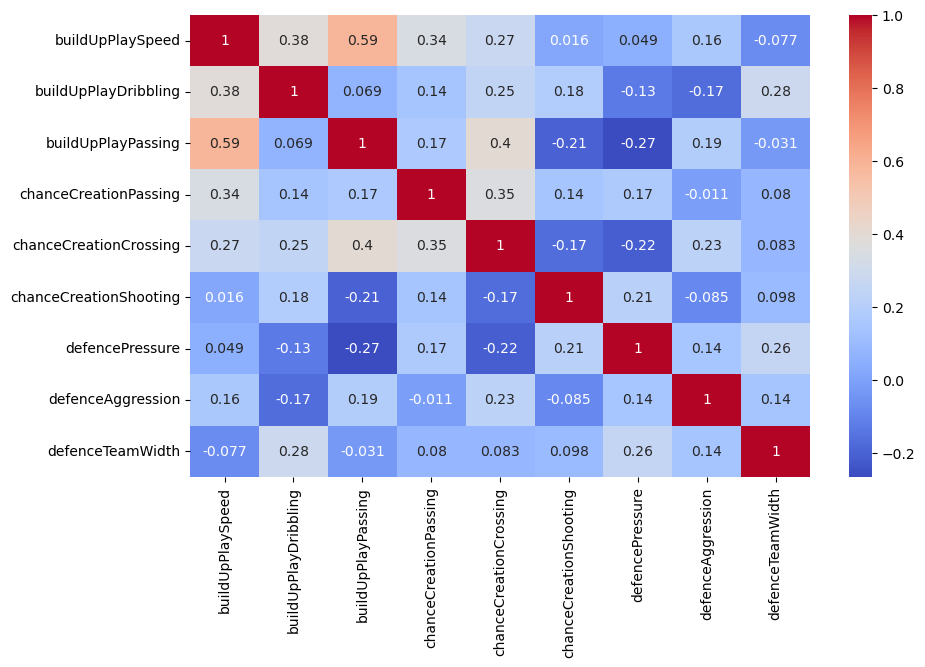

In [5]:
# een lijst met alleen numerieke eigenschappen.
numerieke_eigenschappen = [
    'buildUpPlaySpeed', 'buildUpPlayDribbling', 'buildUpPlayPassing',
    'chanceCreationPassing', 'chanceCreationCrossing', 'chanceCreationShooting', 
    'defencePressure', 'defenceAggression', 'defenceTeamWidth']

# Bereken de correlatie
corr = laliga[numerieke_eigenschappen].corr()

# maak een heatmap van de correlatie
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

**Toelichting heatmap**

Er is eerst een heatmap gemaakt met alle eigenschappen die nummerieke variabelen bevatten om te kijken hoe ze allemaal met gecorreleerd staan. Hieruit blijk dat alleen 'buildUpPlayPassing' en  'buildUpPlaySpeed' sterke samenhang hebben en de andere eigenschappen matig tot zwak samenhang hebben met elkaar.(Turney, S. (2023, March 13))

--------------------

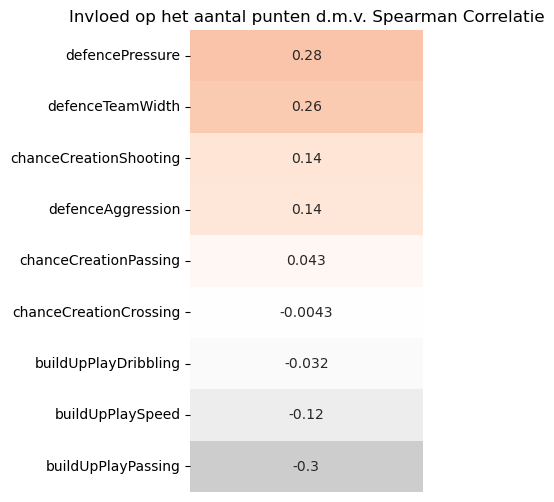

In [23]:
# een lijst met alleen numerieke eigenschappen.
numerieke_eigenschappen = [
    'buildUpPlaySpeed', 'buildUpPlayDribbling', 'buildUpPlayPassing',
    'chanceCreationPassing', 'chanceCreationCrossing', 'chanceCreationShooting', 
    'defencePressure', 'defenceAggression', 'defenceTeamWidth']

# Voeg 'Totaal_Punten' toe aan de lijst van numerieke eigenschappen
numerieke_eigenschappen_totaal_punten = numerieke_eigenschappen + ['Totaal_Punten']

# Bereken de correlatie
corr = laliga[numerieke_eigenschappen_totaal_punten].corr(method='spearman')

corr_totaal_punten = corr[['Totaal_Punten']].sort_values(by='Totaal_Punten', ascending=False)

# Selecteer de kolom, sorteer, EN voeg .drop() toe om de rij zelf te verwijderen
corr_totaal_punten = corr[['Totaal_Punten']].sort_values(by='Totaal_Punten', ascending=False).drop('Totaal_Punten')


plt.figure(figsize=(3, 6)) 
sns.heatmap(corr_totaal_punten, annot=True, cmap='RdGy_r', cbar=False, vmin=-1, vmax=1)
plt.title('Invloed op het aantal punten d.m.v. Spearman Correlatie')

# Dit haalt de tekst aan de onderkant weg
plt.xlabel('')
plt.xticks([]) 

plt.show()

**Correlatie soort**

Voor deze visualisatie is gekozen voor de Spearman correlatie in plaats van de standaard Pearson-methode. Deze beslissing is gebaseerd op de volgende dingen:
- Geen normale verdeling: Uit de histogrammen blijkt dat vrijwel alle variabelen niet normaal verdeeld zijn
- Uitschieters: Bepaalde variabelen hebben veel uitschieters zoals bijv. Totaal_Punten

**Conclusie heatmap**

Uit de heatmap valt op dat de individuele numerieke eigenschappen een zwak tot matig verband (Turney, S. (2023, March 13)) tonen met het totaal aantal punten. Dit is een belangrijk inzicht, het succes van een team hangt niet af van slechts één specifieke eigenschap, maar het hangt af van balans tussen alle eigenschappen.

Turney, S. (2023, March 13). Pearson Correlatiecoëfficiënt (r) Berekenen en Interpreteren. Scribbr. https://www.scribbr.nl/statistiek/pearson-correlatie/

--------------------------------------

In [7]:
# Het maken van een bar chart per eigenschap met zelfgecreëerde functie
def toon_team_vergelijking(df, kolom):
    """
    Maakt een bar chart met alle teams voor een specifieke kolom.
    FC Barcelona wordt donker blauw gekleurd om te zien hoe zij tegen over andere teams staan.

    Args:
        df (pd.DataFrame): Het dataframe met de teamgegevens.
        kolom (str): De naam van de numerieke kolom die geanalyseerd moet worden.
    """

    data = df.groupby('Teamnaam')[kolom].mean().sort_values(ascending=False).reset_index() # Bereken het gemiddelde per team voor de kolom  
    
    plt.figure(figsize=(10, 6))
    
    kleur = ['blue' if team == 'FC Barcelona' else 'lightblue' for team in data['Teamnaam']]  # Kleur FC Barcelona blauw en de rest licht blauw
    
    sns.barplot(data=data, x=kolom, y='Teamnaam', palette=kleur) # Maak een bar chart met de gemiddelde score per team voor de kolom
    
    # Hierin word FC Barcelona donker blauw gekleurd en dikgedrukt op de y-as weergeven.
    for label in plt.gca().get_yticklabels():
        if label.get_text() == 'FC Barcelona':
            label.set_weight('bold') 
            label.set_color('blue')

    # Opmaak van de grafiek    
    plt.title(f'Vergelijking: {kolom}', fontsize=16)
    plt.xlabel(f'Gemiddelde score voor {kolom}')
    plt.ylabel('Team')
    plt.show()

**Opbouw van het spel**

C:\Users\tijnd\AppData\Local\Temp\ipykernel_24904\2938069055.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x=kolom, y='Teamnaam', palette=kleur) # Maak een bar chart met de gemiddelde score per team voor de kolom


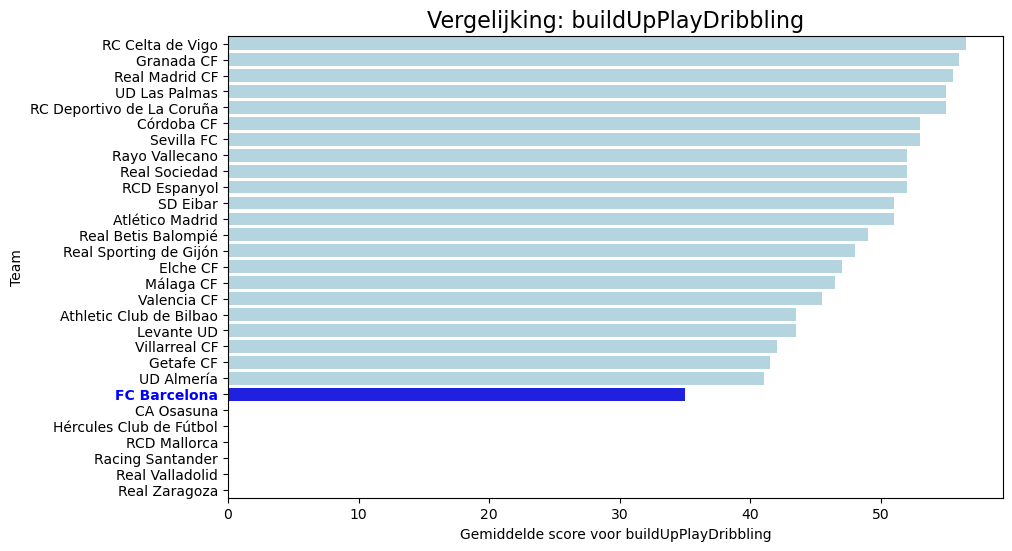

In [8]:
# Analyse van opbouw van dribbelen
toon_team_vergelijking(laliga, 'buildUpPlayDribbling')

C:\Users\tijnd\AppData\Local\Temp\ipykernel_24904\2938069055.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x=kolom, y='Teamnaam', palette=kleur) # Maak een bar chart met de gemiddelde score per team voor de kolom


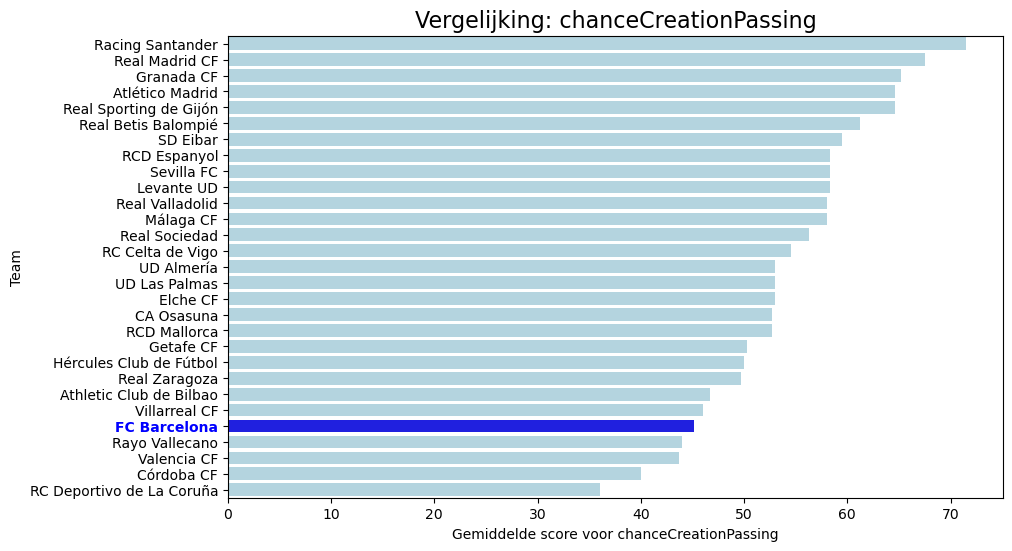

In [9]:
#Analyse van kansen creëren van passing
toon_team_vergelijking(laliga, 'chanceCreationPassing')

C:\Users\tijnd\AppData\Local\Temp\ipykernel_24904\2938069055.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x=kolom, y='Teamnaam', palette=kleur) # Maak een bar chart met de gemiddelde score per team voor de kolom


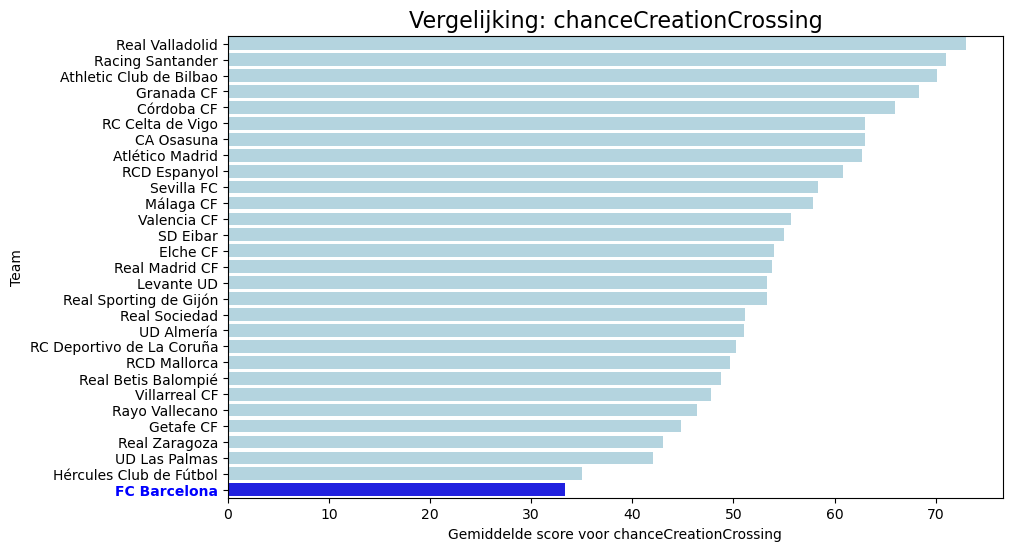

In [10]:
# Analyse van kansen creëren van crossing
toon_team_vergelijking(laliga, 'chanceCreationCrossing')

C:\Users\tijnd\AppData\Local\Temp\ipykernel_24904\2938069055.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x=kolom, y='Teamnaam', palette=kleur) # Maak een bar chart met de gemiddelde score per team voor de kolom


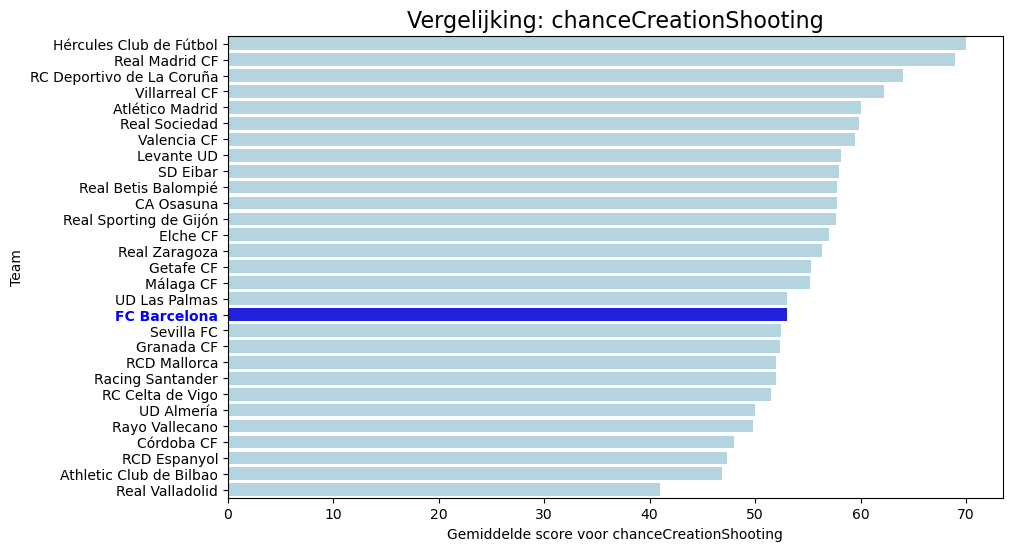

In [11]:
# Analyse van kansen creëren van shooting
toon_team_vergelijking(laliga, 'chanceCreationShooting')

**Defensieve opstelling**

C:\Users\tijnd\AppData\Local\Temp\ipykernel_24904\2938069055.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x=kolom, y='Teamnaam', palette=kleur) # Maak een bar chart met de gemiddelde score per team voor de kolom


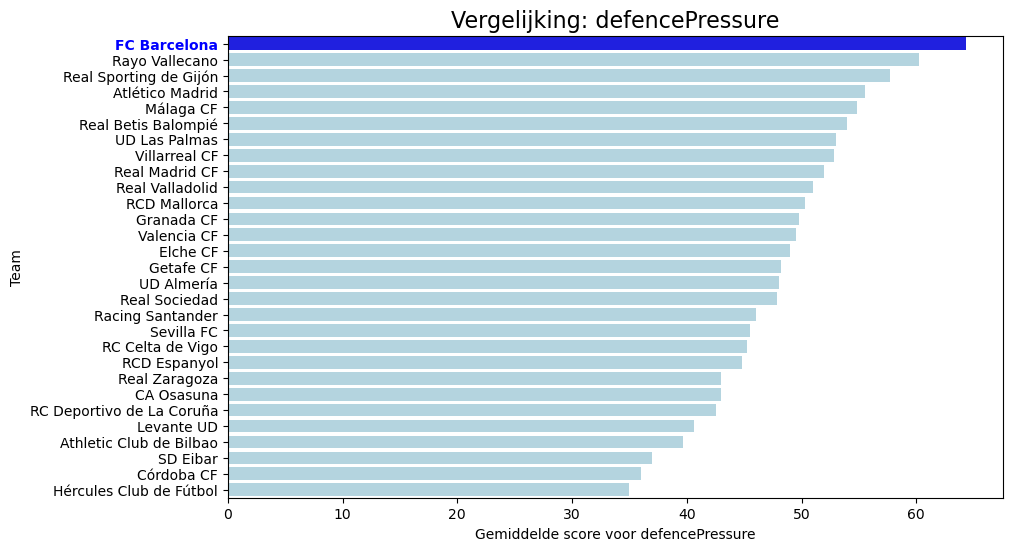

In [12]:
# Analyse van defensieve opstelling op pressure
toon_team_vergelijking(laliga, 'defencePressure')

C:\Users\tijnd\AppData\Local\Temp\ipykernel_24904\2938069055.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x=kolom, y='Teamnaam', palette=kleur) # Maak een bar chart met de gemiddelde score per team voor de kolom


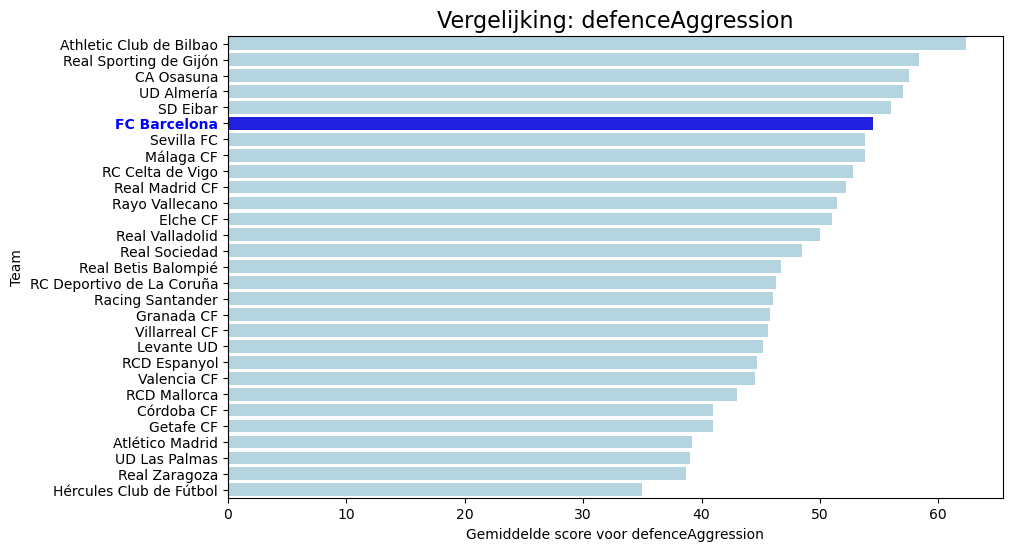

In [13]:
# Analyse van defensieve opstelling op aggression
toon_team_vergelijking(laliga, 'defenceAggression')

C:\Users\tijnd\AppData\Local\Temp\ipykernel_24904\2938069055.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x=kolom, y='Teamnaam', palette=kleur) # Maak een bar chart met de gemiddelde score per team voor de kolom


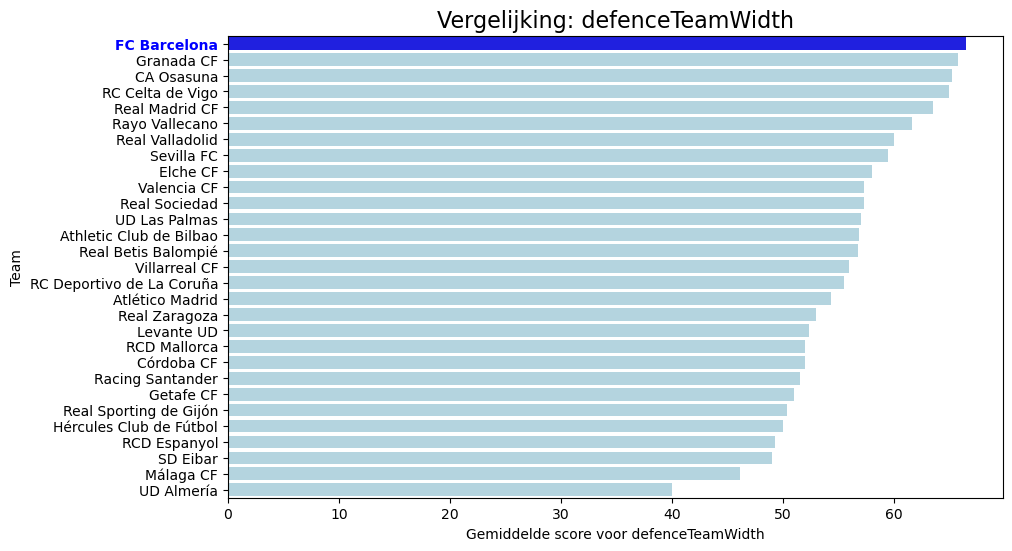

In [14]:
# Analyse van defensieve opstelling op team width
toon_team_vergelijking(laliga, 'defenceTeamWidth')

### **Teameigenschappen (categoriale variabelen)**

In [15]:
# Maak een boxplot om de invloed van een categorische teameigenschap op het totaal aantal punten te visualiseren, met zelfgecreëerde functie.
def toon_categorische_invloed(df, kolom, titel):
    """
    Maakt een boxplot om de invloed van een categorische teameigenschap op het totaal aantal punten te visualiseren.

    Args:
        df (pd.DataFrame): Het dataframe met de teamgegevens.
        kolom (str): De naam van de categorische kolom die geanalyseerd moet worden.
        titel (str): De tekst die als titel boven de grafiek wordt getoond.
    """
    #grootte van de grafiek
    plt.figure(figsize=(8, 6))
    
    # boxplot
    sns.boxplot(data=df, x=kolom, y='Totaal_Punten', palette='Set2')
    
    # Opmaak van de grafiek
    plt.title(titel, fontsize=14)
    plt.ylabel('Totaal Punten')
    plt.xlabel('Teamformatie')
    
    
    plt.show()

C:\Users\tijnd\AppData\Local\Temp\ipykernel_24904\421591765.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=kolom, y='Totaal_Punten', palette='Set2')


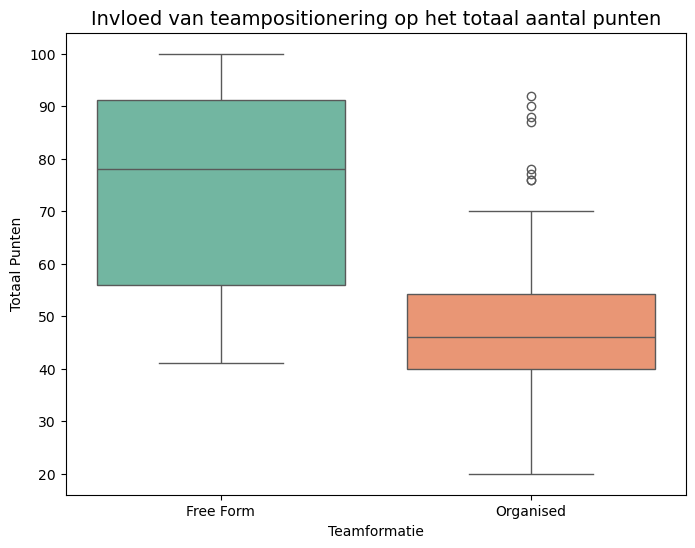

In [16]:
# Teampositionering
toon_categorische_invloed(laliga, 'buildUpPlayPositioningClass', 'Invloed van teampositionering op het totaal aantal punten')

C:\Users\tijnd\AppData\Local\Temp\ipykernel_24904\421591765.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=kolom, y='Totaal_Punten', palette='Set2')


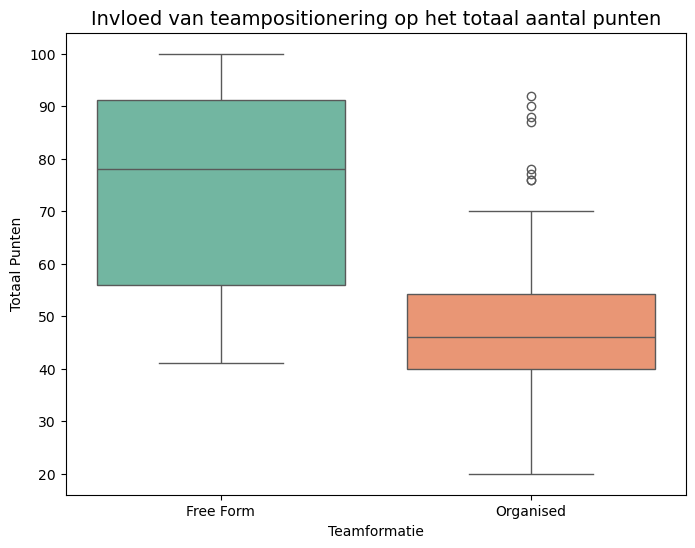

In [17]:
# Teampositionering
toon_categorische_invloed(laliga, 'buildUpPlayPositioningClass', 'Invloed van teampositionering op het totaal aantal punten')

C:\Users\tijnd\AppData\Local\Temp\ipykernel_24904\421591765.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=kolom, y='Totaal_Punten', palette='Set2')


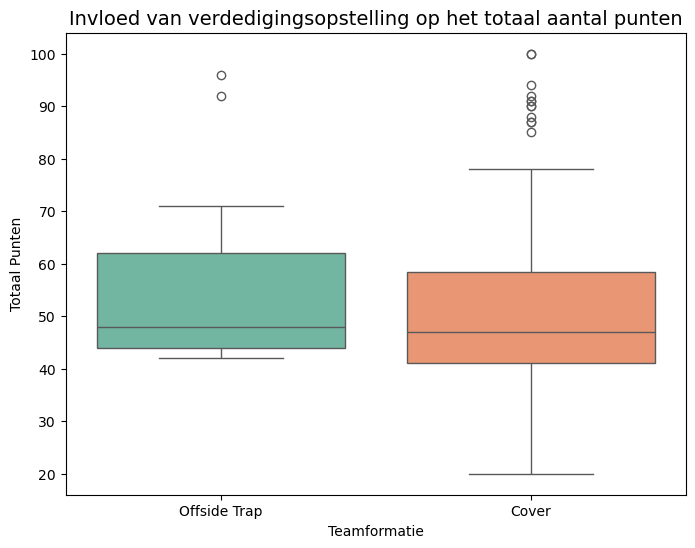

In [18]:
# Verdedigingsopstelling
toon_categorische_invloed(laliga, 'defenceDefenderLineClass', 'Invloed van verdedigingsopstelling op het totaal aantal punten')

**Extra**

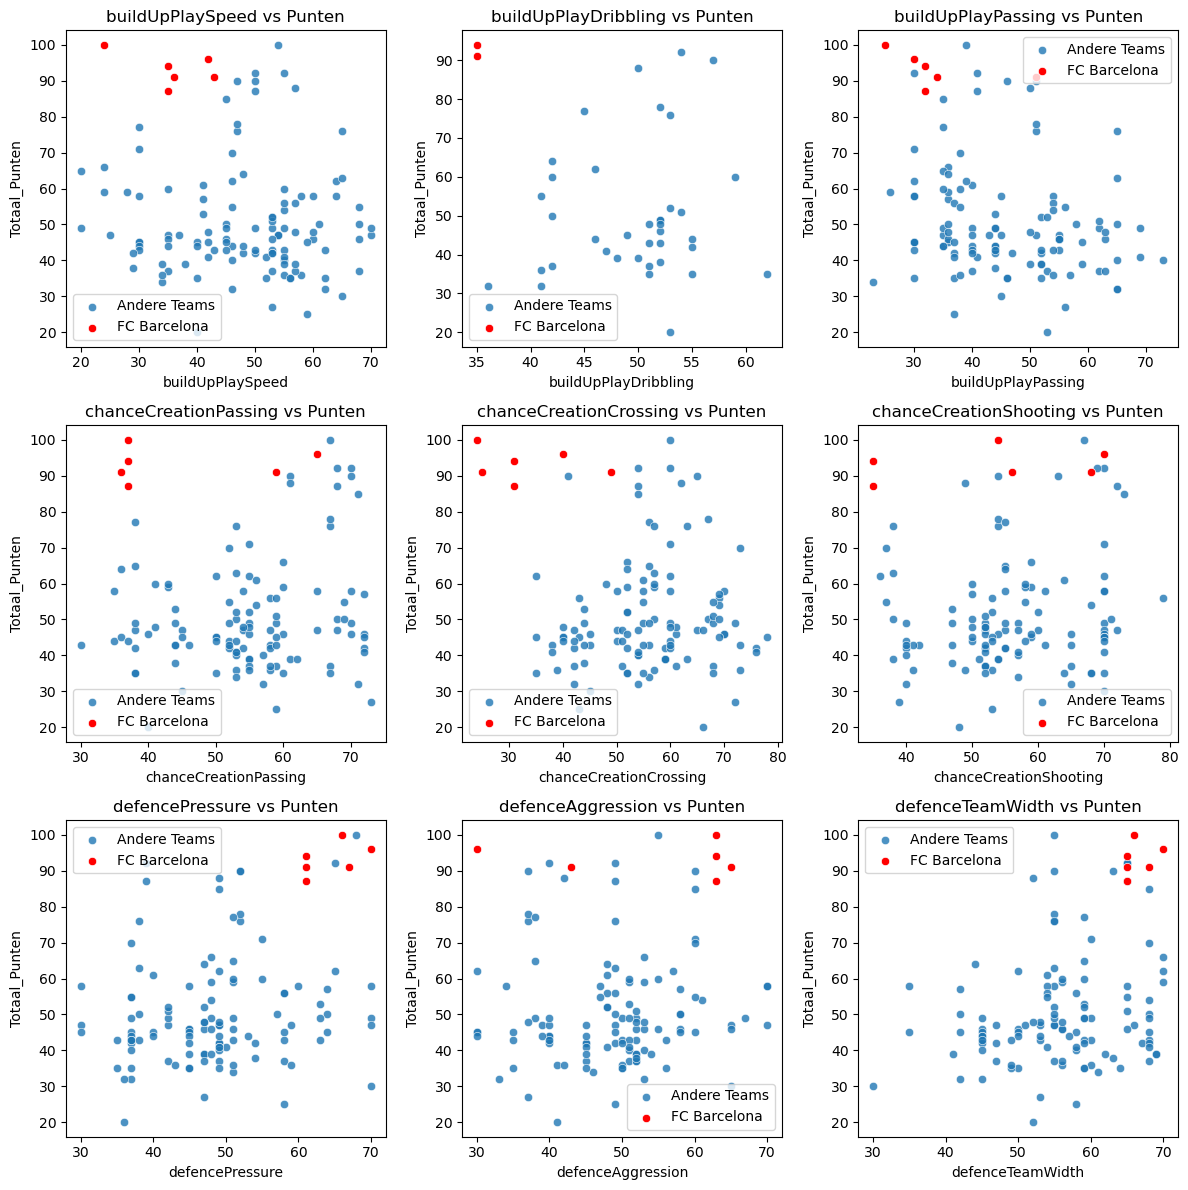

In [19]:

fc_barcelona = laliga[laliga['Teamnaam'] == 'FC Barcelona'] # Filter de data voor FC Barcelona
andere_teams = laliga[laliga['Teamnaam'] != 'FC Barcelona'] # Filter de data voor alle andere teams

# De grootte van de grafiek
plt.figure(figsize=(12, 12))

for i, col in enumerate(numerieke_eigenschappen, 1): # Loop door de numerieke eigenschappen en maak een subplot voor elke eigenschap
    plt.subplot(3, 3, i) # Maak een subplot van 3 rijen en 3 kolommen, en plaats deze op de i positie
    
    # Maak de grafiek eerst voor de andere teams met blauwe kleur.
    sns.scatterplot(data=andere_teams, x=col, y='Totaal_Punten', alpha=0.8, label='Andere Teams')
    
    # Maak dan FC Barcelona eroverheen met rode kleur.
    sns.scatterplot( data=fc_barcelona, x=col, y='Totaal_Punten', 
        color='red', label='FC Barcelona')
    
    plt.title(f'{col} vs Punten') # Geef elke subplot een titel met de naam van de eigenschap

plt.tight_layout() # Zorg ervoor dat de subplots niet overlappen
plt.show()